In [1]:
import scanpy as sc
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scvi as scvi
from IPython.display import display

W0617 20:52:13.417000 15932 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [2]:
os.getcwd()

'c:\\Users\\sanka\\Desktop\\SingleCell_github'

In [2]:
sc.settings.verbosity = 1

In [3]:
os.getcwd()

'C:\\Users\\sanka\\Desktop\\SingleCell_github'

In [4]:
os.chdir('C:\\Users\\sanka\\Desktop\\SingleCell_github\\')

In [5]:
results_file = 'results/run3_pbmc3k.h5ad'

# Load data 

In [6]:
# Read matrix [Counts, Barcodes(cells), and Features(Genes)]
adata = sc.read_10x_mtx(r"C:\Users\sanka\Desktop\SingleCell_github\data\pbmc3k_filtered_gene_bc_matrices\filtered_gene_bc_matrices\hg19")

In [7]:
# # Make the var(gene) name unique 
adata.var_names_make_unique()

# EDA

Number of Cells : 2700
Number of Genes : 32738
Sparsity of the data : 97.41 % 

Number of Mitochondrial Genes : 13
Number of Ribosomal Genes : 106
Number of Hemoglobin Genes : 0

Top 20 Genes Expressed


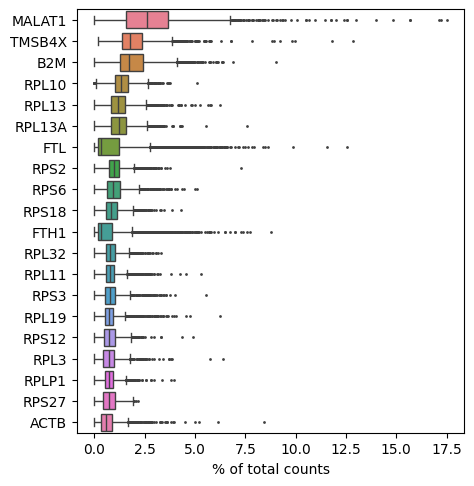



CELL LEVEL QC METRICES SUMMARY 



,n_genes_by_counts,total_counts,pct_counts_Mitochondrial,pct_counts_Ribosomal
count,2700.000000,2700.000000,2700.000000,2700.000000
mean,846.994074,2366.900391,2.215132,34.949211
std,282.104964,1094.262085,1.165438,10.215296
min,212.000000,548.000000,0.000000,1.055966
25%,690.000000,1757.750000,1.536238,26.332963
50%,817.000000,2197.000000,2.029639,36.769516
75%,953.250000,2763.000000,2.640218,43.353328
max,3422.000000,15844.000000,22.569027,59.441711


Minimum Number of Genes in a cell : 212
Maximum Number of Genes in a cell : 3422
Number of cell with less than 300 genes expressed : 15
Mitochondrial Percentage Range : 0 % - 23 %  
Ribosomal Percentage Range : 1 % - 59 %  



GENE LEVEL QC METRICES SUMMARY 



,n_cells_by_counts,total_counts
count,32738.000000,32738.000000
mean,69.854114,195.205292
std,238.263898,2301.482666
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,35.000000,37.000000
max,2700.000000,161685.000000


Minimum number of cells in which a gene is expressed : 0
Maximum number of cells in which a gene is expressed : 2700
Number of Genes which are expressed in less than 3 cells : 19024


In [8]:
def EDA(adata):

    print(f"Number of Cells : {len(adata.obs)}")
    print(f"Number of Genes : {len(adata.var)}")

    Total_elements = len(adata.obs)*len(adata.var) 
    Nonzero_elements = adata.X.nnz
    print(f"Sparsity of the data : {((Total_elements-Nonzero_elements)/Total_elements)*100:.2f} % \n")

    # Identification of Mitochondrial, Ribosomal and Hemoglobin Genes
    adata.var["Mitochondrial"] = adata.var_names.str.startswith("MT-")  # MORE MT = DYING CELL BUT DEPENDS UPON THE CELL TYPE 
    adata.var["Ribosomal"] = adata.var_names.str.startswith(("RPS","RPL")) 
    adata.var["Hemo"] = adata.var_names.str.startswith("^HB[^(P)]")

    print(f"Number of Mitochondrial Genes : {(adata.var["Mitochondrial"]).sum()}")
    print(f"Number of Ribosomal Genes : {(adata.var["Ribosomal"]).sum()}")
    print(f"Number of Hemoglobin Genes : {(adata.var["Hemo"]).sum()}\n")

    # PLotting the top 20 highly expressed genes
    print("Top 20 Genes Expressed")
    sc.pl.highest_expr_genes(adata, n_top=20)

    # Calculating per cell level qc metrices
    sc.pp.calculate_qc_metrics(adata,percent_top=None,log1p=False,qc_vars =['Mitochondrial','Ribosomal','Hemo'] ,inplace=True )
    print("\n")  
    
    # CELL LEVEL QC METRICES
    print("CELL LEVEL QC METRICES SUMMARY \n")
    cell_qc = adata.obs[['n_genes_by_counts','total_counts','pct_counts_Mitochondrial','pct_counts_Ribosomal']].describe()
    display(cell_qc)
    print(f"Minimum Number of Genes in a cell : {min(adata.obs['n_genes_by_counts'])}")
    print(f"Maximum Number of Genes in a cell : {max(adata.obs['n_genes_by_counts'])}")
    print(f"Number of cell with less than 300 genes expressed : {(adata.obs['n_genes_by_counts'] < 300 ).sum()}")
    print(f"Mitochondrial Percentage Range : {min(adata.obs['pct_counts_Mitochondrial']):.0f} % - {max(adata.obs['pct_counts_Mitochondrial']):.0f} %  ")
    print(f"Ribosomal Percentage Range : {min(adata.obs['pct_counts_Ribosomal']):.0f} % - {max(adata.obs['pct_counts_Ribosomal']):.0f} %  ")
    print("\n\n")  

    # GENE LEVEL METRICES 
    print("GENE LEVEL QC METRICES SUMMARY \n")
    gene_qc = adata.var[['n_cells_by_counts','total_counts']].describe()
    display(gene_qc)
    print(f"Minimum number of cells in which a gene is expressed : {min(adata.var["n_cells_by_counts"])}")
    print(f"Maximum number of cells in which a gene is expressed : {max(adata.var["n_cells_by_counts"])}")
    print(f"Number of Genes which are expressed in less than 3 cells : {(adata.var["n_cells_by_counts"] < 3).sum()}")

    summary_stats = {
    "n_cells": len(adata.obs),
    "n_genes": len(adata.var),
    "sparsity": ((Total_elements-Nonzero_elements)/Total_elements)*100,
    "n_mt_genes": adata.var["Mitochondrial"].sum(),
    "n_ribo_genes": adata.var["Ribosomal"].sum(),
    "n_hemo_genes": adata.var["Hemo"].sum(),
    "cells_lt_300_genes": (adata.obs['n_genes_by_counts'] < 300).sum(),
    "genes_lt_3_cells": (adata.var["n_cells_by_counts"] < 3).sum()
    }

    return summary_stats, cell_qc, gene_qc

summary_stats , cell_qc , gene_qc = EDA(adata)

#### Visualizing QC Metrices

In [9]:
# Plotting QC Metrices 

def Plotting(adata): 

    # Figure path 
    figure_path = 'Figures/'
    
    # Setting the figure and axes objects for a 3x1 grid
    fig, axes = plt.subplots(nrows=1, ncols=6 , figsize=(45, 8))

    # FIGURE 1A : GENES DISTRIBUTION
    fig_1 = axes[0]
    fig_1.hist(adata.obs['n_genes_by_counts'], bins = 50, alpha= 0.7 , color='steelblue',edgecolor='black')
    fig_1.set_xlabel("Genes per cell")
    fig_1.set_ylabel("Number of cells")
    fig_1.set_title("Gene Distribution")
    fig_1.axvline(np.median(adata.obs['n_genes_by_counts']), color = 'red', linestyle = '--', label = f"Median {np.median(adata.obs['n_genes_by_counts']):.0f}")
    fig_1.legend()

    # FIGURE 1B : GENE DISTRIBUTION VIOLIN PLOT  
    ax1_viol = axes[1]
    sc.pl.violin(adata, "n_genes_by_counts", jitter=0.4, ax=ax1_viol, show=False )
    ax1_viol.set_title("Genes per cell (Violin Plot)")
    ax1_viol.set_xlabel("") # Clear redundant x-label

    # FIGURE 2A : UMI DISTRIBUTION
    fig_2 = axes[2]
    fig_2.hist(adata.obs['total_counts'], bins = 50, alpha= 0.7 , color='yellow',edgecolor='black')
    fig_2.set_xlabel("UMI per cell")
    fig_2.set_ylabel("Number of cells")
    fig_2.set_title("UMI Distribution")
    fig_2.axvline(np.median(adata.obs['total_counts']), color = 'red', linestyle = '--', label = f"Median {np.median(adata.obs['total_counts']):.0f}")
    fig_2.legend()

    # FIGURE 2B : UMI DISTRIBUTION Violin Plot
    ax2_viol = axes[3]
    sc.pl.violin(adata, "total_counts", jitter=0.4, ax=ax2_viol, show=False)
    ax2_viol.set_title("UMI Counts per cell (Violin Plot)")
    ax2_viol.set_xlabel("")
    
    # FIGURE 3A : MITOCHONDRIAL DISTRIBUITON
    fig_3 = axes[4]
    fig_3.hist(adata.obs['pct_counts_Mitochondrial'], bins = 50, alpha= 0.7 , color='green',edgecolor='black')
    fig_3.set_xlabel("Mitochondrial % per cell")
    fig_3.set_ylabel("Number of cells")
    fig_3.set_title("Mitochondiral Distribution")
    fig_3.axvline(np.median(adata.obs['pct_counts_Mitochondrial']), color = 'red', linestyle = '--', label = f"Median {np.median(adata.obs['pct_counts_Mitochondrial']):.2f} %")
    fig_3.legend()

    # FIGURE 3B : MITOCHONDRIAL DITRIBUTION VIOLIN PLOT
    ax3_viol = axes[5]
    sc.pl.violin(adata, "pct_counts_Mitochondrial", jitter=0.4, ax=ax3_viol, show=False)
    ax3_viol.set_title("Mitochondrial % (Violin Plot)")
    ax3_viol.set_xlabel("")

    plt.savefig(f"{figure_path}/01_qc_plots.png" ,bbox_inches="tight")
    plt.close()

Plotting(adata)

## Preprocessing | Quality Control

### Basic filtering based on Graphs

In [43]:
adata_qc = adata.copy()

In [44]:
# Cell filtering 
sc.pp.filter_cells(adata_qc,min_genes = 200)
sc.pp.filter_cells(adata_qc,max_genes = 2500)

# Gene filtering 
sc.pp.filter_genes(adata_qc,min_cells = 3 )  # ~58 % of genes are not expressed in 3 cells | 32738 - 19024 = 13714

In [45]:
adata_qc

AnnData object with n_obs × n_vars = 2695 × 13673
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_Mitochondrial', 'pct_counts_Mitochondrial', 'total_counts_Ribosomal', 'pct_counts_Ribosomal', 'total_counts_Hemo', 'pct_counts_Hemo', 'n_genes'
    var: 'gene_ids', 'Mitochondrial', 'Ribosomal', 'Hemo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

In [46]:
# Removing Mitochondrial Genes  
adata_qc = adata_qc[adata_qc.obs['pct_counts_Mitochondrial'] < 5 , : ]

In [47]:
print(f"Cells Before filtering : {len(adata.obs)}")
print(f"Genes Before filtering : {len(adata.var)}\n ")

print(f"Cells after filtering : {len(adata_qc.obs)}")
print(f"Genes after filtering : {len(adata_qc.var)}")

Cells Before filtering : 2700
Genes Before filtering : 32738
 
Cells after filtering : 2638
Genes after filtering : 13673


# Normalisation

In [48]:
adata_qc.layers['counts'] = adata_qc.X.copy()

C:\Users\sanka\AppData\Local\Temp\ipykernel_25472\1416119010.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata_qc.layers['counts'] = adata_qc.X.copy()


In [49]:
sc.pp.normalize_total(adata_qc , target_sum = 1e4 )

In [50]:
sc.pp.log1p(adata_qc)

# HVG

In [51]:
sc.pp.highly_variable_genes(
    adata_qc,
    flavor="seurat_v3",
    n_top_genes=2000,
    layer="counts"
)

C:\Users\sanka\AppData\Local\Temp\ipykernel_25472\3302737342.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.highly_variable_genes(adata_qc, save='highly_variable_genes.png')


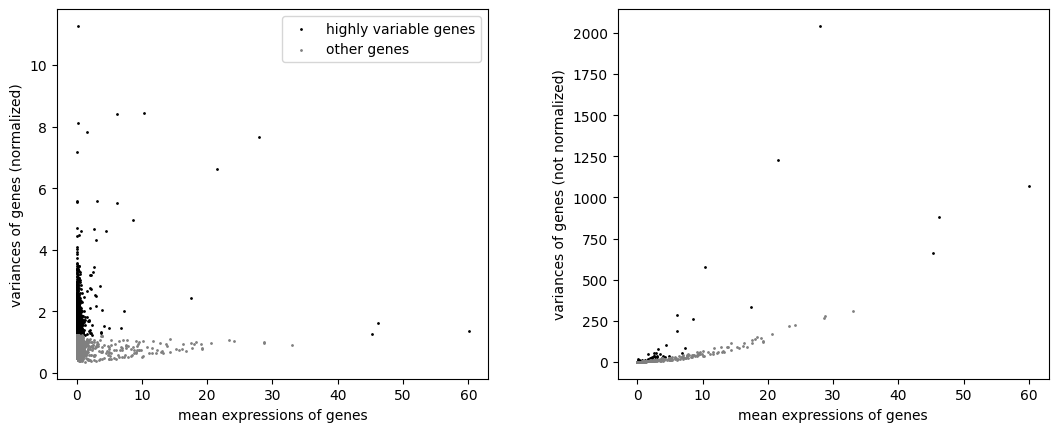

In [52]:
sc.pl.highly_variable_genes(adata_qc, save='highly_variable_genes.png')

In [21]:
adata_qc = adata_qc[:, adata_qc.var.highly_variable] 

In [22]:
adata_qc = adata_qc.copy()

In [53]:
# Regression removes unwanted technical effects
sc.pp.regress_out(adata_qc, ['total_counts','pct_counts_Mitochondrial','pct_counts_Ribosomal'])

In [54]:
# Scaling sets every gene on a same variance scale 
sc.pp.scale(adata_qc, max_value = 10)

# Dimensionality Reduction

In [55]:
# Calculating PCs 
sc.tl.pca(adata_qc)

# BY DEFAULT IT CALCULATES 50 PCs
# Results stored in adata_qc.obsm["X_pca"]

C:\Users\sanka\AppData\Local\Temp\ipykernel_25472\4285427793.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca_variance_ratio(adata_qc, n_pcs = 50 , log = True , save = '03_dimensional_reduction.png')


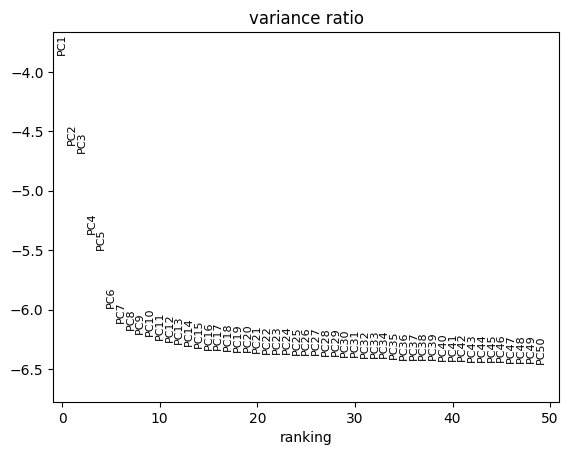

In [56]:
sc.pl.pca_variance_ratio(adata_qc, n_pcs = 50 , log = True , save = '03_dimensional_reduction.png')

C:\Users\sanka\AppData\Local\Temp\ipykernel_25472\1289364845.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca_loadings(adata_qc, components=(1, 2), include_lowest=True,save = '05_PC1_PC2_contributions.png' )


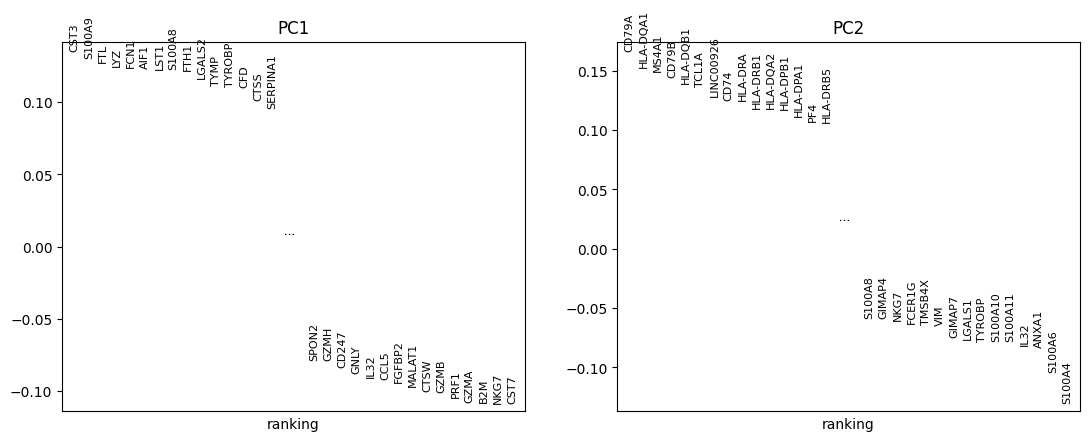

In [57]:
# Checking which genes contributes to pca1 and pca2 
sc.pl.pca_loadings(adata_qc, components=(1, 2), include_lowest=True,save = '05_PC1_PC2_contributions.png' )

# Computing the neighborhood graph

In [58]:
sc.pp.neighbors(adata_qc, n_neighbors=10, n_pcs=40)

# Embedding the Neighbourhood Graph

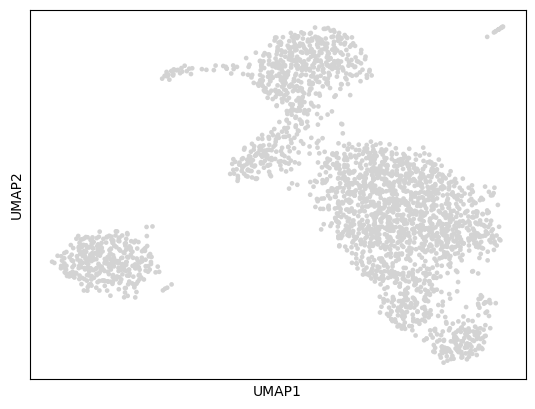

In [59]:
sc.tl.umap(adata_qc)
sc.pl.umap(adata_qc)

# Clustering 

In [60]:
!pip install leidenalg


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [67]:
# Clustering Using the Leiden Algorithm 
sc.tl.leiden(adata_qc, resolution = 0.8,flavor = "igraph" , n_iterations = 2 )

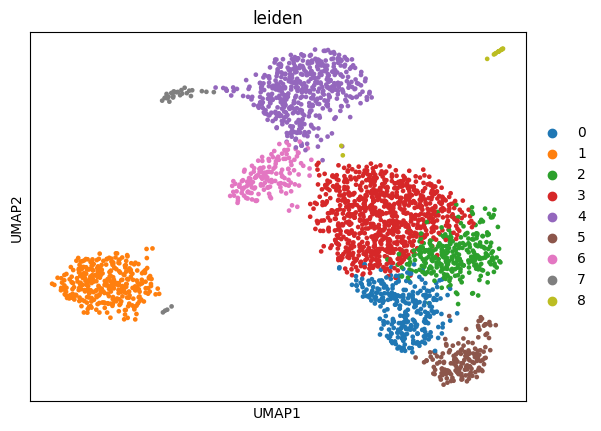

In [68]:
sc.pl.umap(adata_qc , color = "leiden", show = False)
plt.savefig('Figures/04_Leiden_clustering.png')
plt.show()

# Alternative code : sc.pl.umap(adata_qc , color = "leiden", save = 'Figures/04_Leiden_clustering.png')

# Cell Type annotation

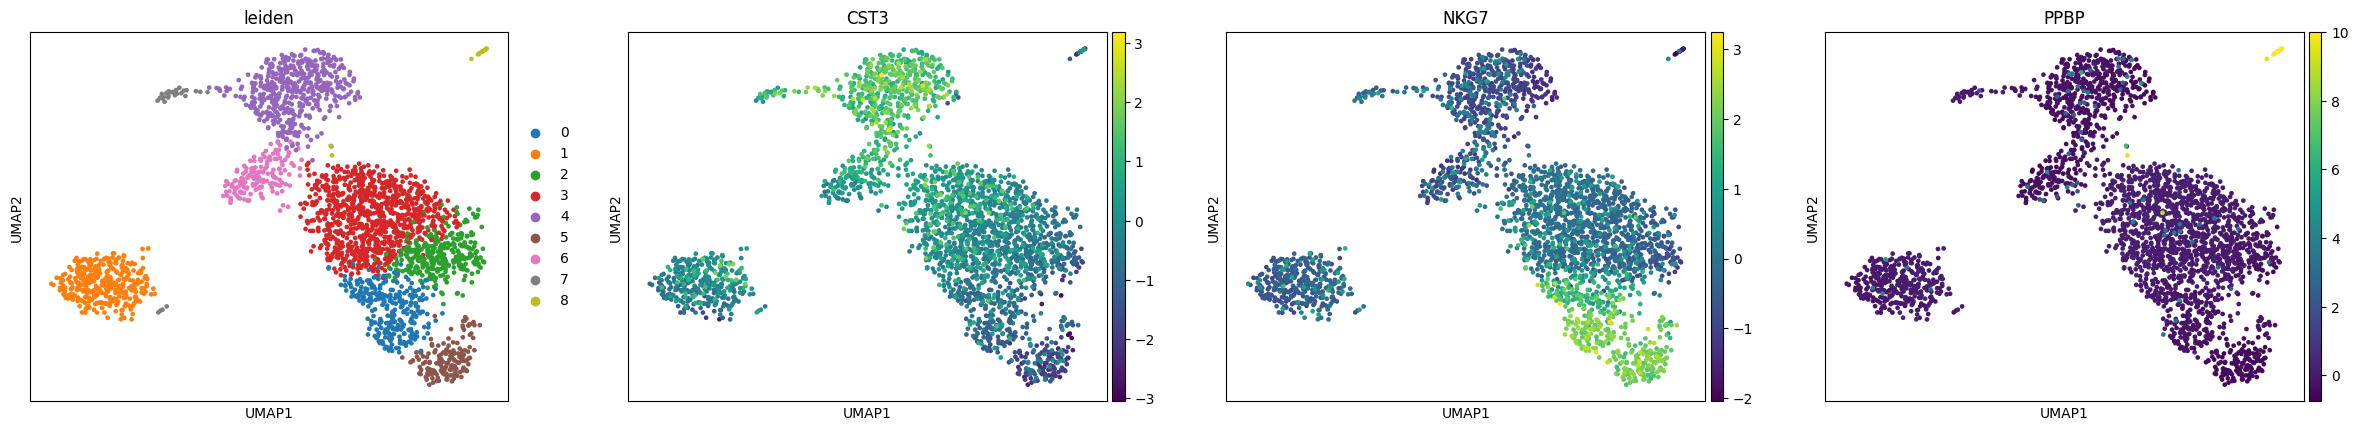

In [69]:
sc.pl.umap(adata_qc , color = ["leiden","CST3","NKG7","PPBP"])

C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: inv

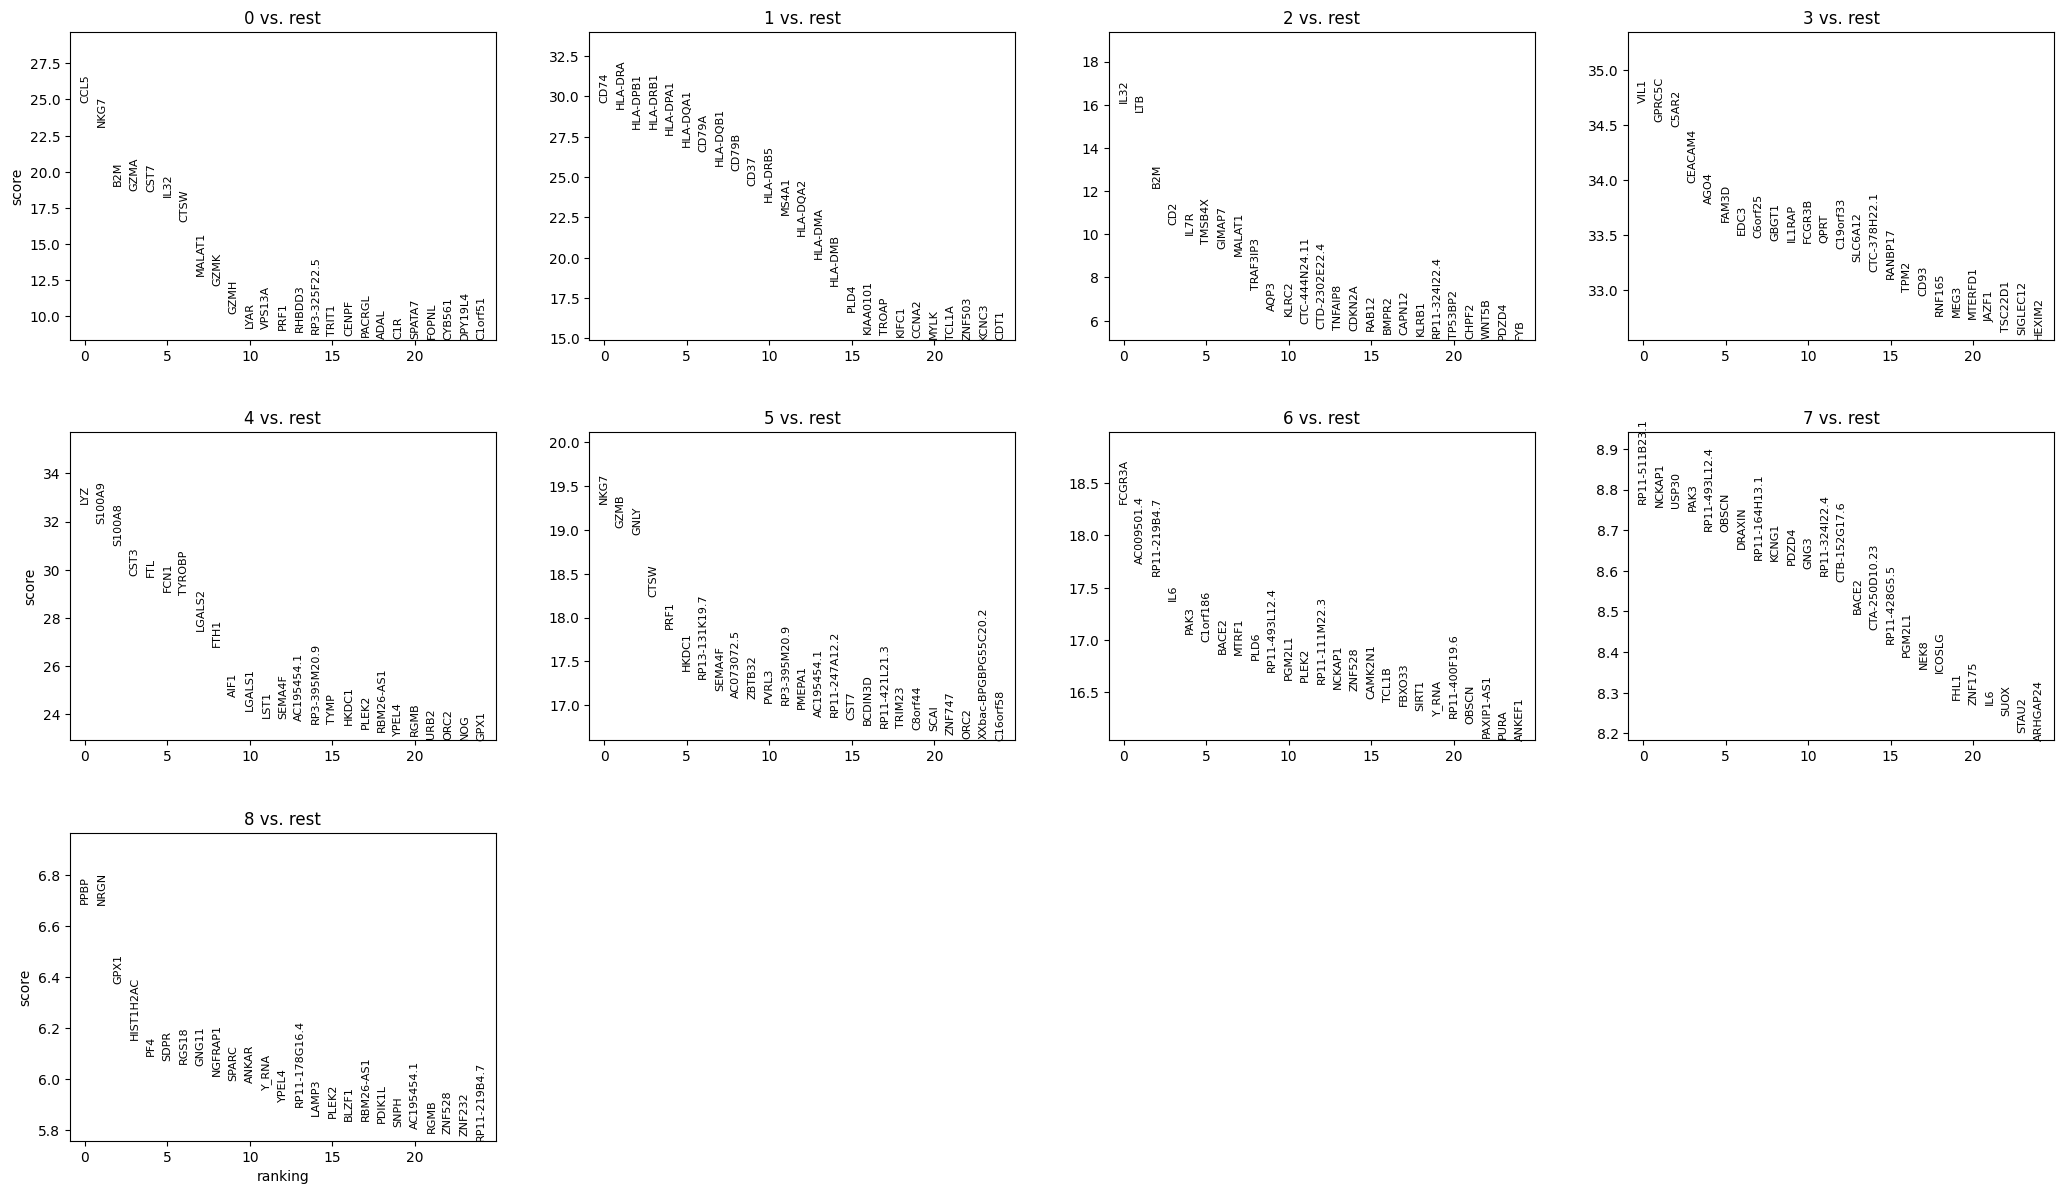

In [70]:
sc.tl.rank_genes_groups(adata_qc, "leiden", mask_var="highly_variable", method='wilcoxon')
sc.pl.rank_genes_groups(adata_qc, n_genes=25, sharey=False)

In [71]:
# Top 10 Expressed genes in clusters
pd.DataFrame(adata_qc.uns['rank_genes_groups']['names']).head(10)

,0,1,2,3,4,5,6,7,8
0,CCL5,CD74,IL32,VIL1,LYZ,NKG7,FCGR3A,RP11-511B23.1,PPBP
1,NKG7,HLA-DRA,LTB,GPRC5C,S100A9,GZMB,AC009501.4,NCKAP1,NRGN
2,B2M,HLA-DPB1,B2M,C5AR2,S100A8,GNLY,RP11-219B4.7,USP30,GPX1
3,GZMA,HLA-DRB1,CD2,CEACAM4,CST3,CTSW,IL6,PAK3,HIST1H2AC
4,CST7,HLA-DPA1,IL7R,AGO4,FTL,PRF1,PAK3,RP11-493L12.4,PF4
5,IL32,HLA-DQA1,TMSB4X,FAM3D,FCN1,HKDC1,C1orf186,OBSCN,SDPR
6,CTSW,CD79A,GIMAP7,EDC3,TYROBP,RP13-131K19.7,BACE2,DRAXIN,RGS18
7,MALAT1,HLA-DQB1,MALAT1,C6orf25,LGALS2,SEMA4F,MTRF1,RP11-164H13.1,GNG11
8,GZMK,CD79B,TRAF3IP3,GBGT1,FTH1,AC073072.5,PLD6,KCNG1,NGFRAP1
9,GZMH,CD37,AQP3,IL1RAP,AIF1,ZBTB32,RP11-493L12.4,PDZD4,SPARC


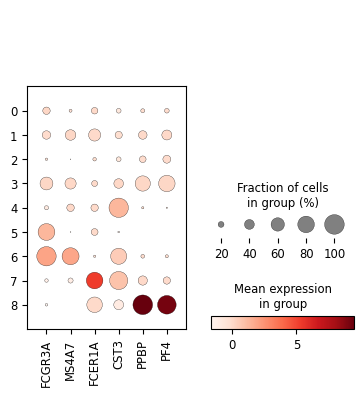

In [72]:
sc.pl.dotplot(
    adata_qc,
    ["FCGR3A","MS4A7","FCER1A","CST3","PPBP","PF4"],
    groupby="leiden"
)

In [57]:
adata_qc.write(results_file)